{'EC186': 'Pt 1', 'EC222': 'Pt 2', 'EC133': 'Pt 3', 'EC191': 'Pt 4', 'EC196': 'Pt 5', 'EC175': 'Pt 6', 'EC220': 'Pt 7', 'EC221': 'Pt 8', 'EC157': 'Pt 9', 'EC135': 'Pt 10', 'EC219': 'Pt 11', 'EC162': 'Pt 12', 'EC143': 'Pt 13', 'EC137': 'Pt 14', 'EC187': 'Pt 15', 'EC130': 'Pt 16', 'EC183': 'Pt 17'}
(3383, 1000)
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
15 [np.float64(0.8834423599704139), np.float64(0.9391807811959904), np.float64(0.9712676886792453), np.float64(0.9125695216907674), np.float64(0.973783988733615), np.float64(0.9695121951219512), np.float64(0.9694715007215007), np.float64(0.9785367545076282), np.float64(0.9857521204197258), np.float64(0.9718076285240465), np.float64(0.987524936463258), np.float64(0.9787876950440618), np.float64(0.9636363636363637), np.float64(0.9900692692521487), np.float64(0.9977151561309977)] 1.0
what is the length of tru tpr:  15
(15, 1000)


<Figure size 800x600 with 0 Axes>

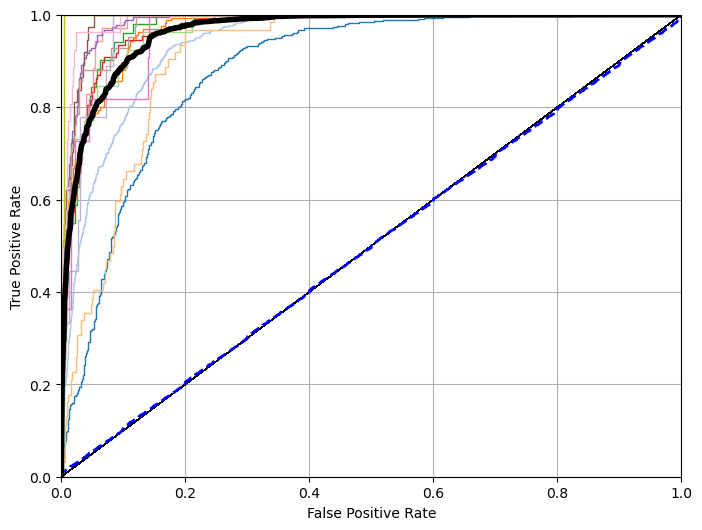

(0.0, 10.0)

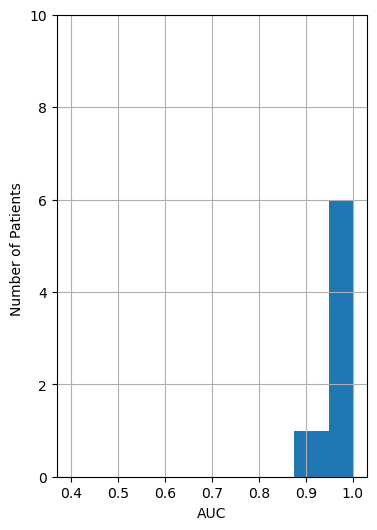

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import numpy as np
from sklearn.metrics import RocCurveDisplay, auc
import matplotlib.colors as mcolors
from matplotlib.patches import Patch


import json

with open('patient_rename.txt') as f:
    data = f.read()
js = json.loads(data)
print(js)


import json

# Load the dictionary from the text file
with open('patient_recolor.txt', 'r') as file:
    js_color = json.load(file)


new_patient_color = {new_name: js_color[name] for name, new_name in js.items()}
# legend_patches = [Patch(color=hex_code, label=new_name) for new_name, hex_code in new_patient_color.items()]
# legend_patches = [Patch(color=hex_code, label=new_name) for new_name, hex_code in js_color.items()]



list1=[]
list2=[]
count = 0
tpr_list = []
fpr_list = []
tprs = []

# infile1 = open("tttt_label_file.txt","r")
# infile2 = open("tttt_pred_file.txt","r")
mean_fpr = np.linspace(0, 1.0, 1000)

plt.figure(figsize=(8, 6))

plt.plot([0, 1], [0, 1], 'k-', linewidth=0.5)
# plt.plot(recall1, precision1, marker='.', label='Precision-Recall Score:(area = {:.3f})'.format(auc_precision_recall))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.ylim(0.0,1.0)
plt.xlim(0.0,1.0)


pt_ch_mapping ={
            # "EC130_513": [3],
            "EC186_200": [299, 300, 301],
            "EC222_200": [267, 268, 269, 270],
            "EC133_200": [282, 291, 292, 293],
            "EC191_200": [2, 3, 4],
            "EC196_200": [300, 301, 303],
            "EC175_200": [301, 302],
            "EC220_200": [53, 54, 76, 77],
            "EC221_200": [376, 377],
            "EC157_200": [321, 332, 333, 334],
            "EC135_200": [303],
            "EC219_200": [399, 400, 402, 403],
            "EC162_200": [85, 86],
            "EC143_200": [339],
            "EC137_200": [257, 258, 259, 269],
            "EC187_200": [309, 310],
            "EC130_200": [1,13],
            "EC183_200": [290]
            }






list1=[]
list2=[]
tpr_list = []
fpr_list = []
tprs = []
aucs = []


mean_fpr = np.linspace(0, 1.0, 1000)

plt.figure(figsize=(8, 6))

for fold, patient_idx in enumerate(pt_ch_mapping.keys()):
    infile1 = open("patient_random_label_file_"+patient_idx[:-4]+"_513.txt","r")
    infile2 = open("patient_random_pred_file_"+patient_idx[:-4]+"_513.txt","r")
    count = 0

    for line1, line2 in zip(infile1, infile2):
        # print(line1[1:-2])
        count += 1
        if count == 200:
            break
        line1_each = line1[1:-2].split(',')
        lines1 = []
        for f in line1_each:
            lines1.append(float(f))

        line2_each = line2[1:-2].split(',')
        lines2 = []
        for f in line2_each:
            lines2.append(float(f))

        plt.figure(1)


        lr_auc = roc_auc_score(lines1, lines2)
        fpr, tpr, _ = roc_curve(lines1, lines2)
        # print(len(fpr), len(tpr))
        

        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(lr_auc)

        # plt.plot(fpr, tpr, marker='.', label=None, color='silver',linewidth=0.3, alpha=0.9)
        plt.plot([0, 1], [0, 1], 'k-', linewidth=0.5)
        # plt.plot(recall1, precision1, marker='.', label='Precision-Recall Score:(area = {:.3f})'.format(auc_precision_recall))
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.ylim(0.0,1.0)
        plt.xlim(0.0,1.0)

plt.figure(1)
print(np.asarray(tprs).shape)
mean_tpr = np.mean(tprs, axis=0)
std_tpr = np.std(tprs, axis=0)

pecent_95 = []
pecent_95_lower = []
tprs = np.asarray(tprs) 
for i in range(tprs.shape[1]):
    p = np.percentile(tprs[:,i], 97.5) 
    p_low = np.percentile(tprs[:,i], 2.5) 
    pecent_95_lower.append(p_low)
    pecent_95.append(p)


mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)


plt.plot(mean_fpr, mean_tpr, marker='.', label= r"Mean Random ROC (AUC = %0.3f $\pm$ %0.3f)" % (mean_auc, std_auc),color='blue',lw=2, linestyle='dashed', markersize=0.01)



aucs = []
label_list = []
true_tprs_all_patients = []
min_auc=float('inf')
max_auc=0.0
count = 0
for fold, patient_idx in enumerate(pt_ch_mapping.keys()):
    if patient_idx == "EC183_200" or patient_idx == "EC130_200":
        continue


    # infile1 = open("true_label_file_"+patient_idx+"_200.txt","r")
    # infile2 = open("true_pred_file_"+patient_idx+"_200.txt","r")

    # infile1 = open("cana_leave_1_label_file_"+patient_idx+"_200.txt","r")
    # infile2 = open("cana_leave_1_pred_file_"+patient_idx+"_200.txt","r")

    infile1 = open("true_label_file_exclude_"+patient_idx+"_200.txt","r")
    infile2 = open("true_pred_file_exclude_"+patient_idx+"_200.txt","r")

    true_tprs = []
    count += 1
    for line1, line2 in zip(infile1, infile2):
        line1_each = line1[1:-2].split(',')
        lines1 = []
        for f in line1_each:
            lines1.append(float(f))

        line2_each = line2[1:-2].split(',')
        lines2 = []
        for f in line2_each:
            lines2.append(float(f))

        lr_auc = roc_auc_score(lines1, lines2)
        fpr, tpr, _ = roc_curve(lines1, lines2)
        aucs.append(lr_auc)

        min_auc = min(min_auc, lr_auc)
        max_auc = max(max_auc, lr_auc)

        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0

        true_tprs.append(interp_tpr)
        
        print(count)
        label_list.append( round(lr_auc,3))
        plt.plot(fpr, tpr, marker='.', color=js_color[patient_idx[:-4]], alpha=1,lw=1,markersize=0.01)
       
        # if count == 15:
        #     plt.plot(fpr, tpr, marker='.', label='AUC range : %0.3f ~ %0.3f'%(min_auc, max_auc),color='cyan', alpha=0.3,lw=0.5,markersize=0.01)
    
        # if count == 5:
        # plt.plot(fpr, tpr, marker='.', label='%s ~ %0.3f'%(js[patient_idx[:-4]], lr_auc), color=js_color[patient_idx[:-4]], alpha=0.6,lw=0.8,markersize=0.01)
        # else:
        #     plt.plot(fpr, tpr, marker='.', color='cyan', alpha=0.3,lw=0.5,markersize=0.01)

    true_tprs_all_patients.append(np.squeeze(np.asarray(true_tprs)))
print(len(aucs),aucs, sum(np.asarray(aucs)>0.51)/15)
print("what is the length of tru tpr: ", str(len(true_tprs_all_patients)))

std_auc = np.std(aucs)
true_tprs_all_patients = np.asarray(true_tprs_all_patients)
print(true_tprs_all_patients.shape)
mean_tpr = np.mean(true_tprs_all_patients, axis=0)
mean_tpr[-1] = 1.0

mean_auc = auc(mean_fpr, mean_tpr)

plt.plot(mean_fpr, mean_tpr, marker='.', label= r"Mean AUC = %0.3f $\pm$ %0.3f, range : %0.3f ~ %0.3f" % (mean_auc, std_auc, min_auc, max_auc ),color='black',lw=4,markersize=0.01)
# plt.legend(handles=legend_patches, loc="lower right")
# plt.legend(loc="lower right")
plt.grid(True)
plt.show()
# plt.savefig("aaaaaaaaaaaa_true_exclude_label_200_add.png", dpi=1200)
# plt.savefig("aaaaaaaaaaaa_cana_exclude_label_200_add.png", dpi=1200)
# plt.savefig("aaaaaaaaaaaa_true_exclude_auto_label_200_add.png", dpi=1200)


plt.figure(figsize=(4, 6))
plt.hist(aucs, range=[0.4, 1.0], density=False, bins=24)  # density=False would make counts

# plt.ylabel('Data (Samples = %s)'% str(count_id))
plt.ylabel('Number of Patients ')
plt.xlabel('AUC')
plt.grid(True)
plt.ylim(0, 10)
# plt.axvline(x = 0.5, color = 'r', linestyle = '--',linewidth=0.5, label = 'axvline - full height')

# plt.savefig("hist_for_each_patient.png")